In [1]:
import pandas as pd
import numpy as np


df =pd.read_csv("Fitbit_dataset.csv")

In [2]:
df.shape

(14102, 19)

In [3]:
df

,Unnamed: 0,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Base_MET,HR_Intensity,Effective_MET,Calories_Burned (kcal)
0,0,56,Female,53.8,1.62,163.0,149.0,71.0,1.01,HIIT,22.1,3.5,3,1,20.4,9.5,0.847826,8.054348,437.7
1,1,46,Male,54.9,1.75,170.0,126.0,73.0,0.25,Yoga,19.9,3.4,3,0,18.0,3.0,0.546392,1.639175,22.5
2,2,32,Female,68.5,1.61,190.0,171.0,60.0,0.33,HIIT,20.4,2.7,3,1,26.5,9.5,0.853846,8.111538,183.4
3,3,25,Male,98.8,1.86,189.0,135.0,69.0,0.78,Yoga,30.3,4.4,3,0,28.5,3.0,0.550000,1.650000,127.2
4,4,38,Male,95.5,1.71,176.0,138.0,66.0,0.55,Cardio,23.7,2.2,2,0,32.5,7.0,0.654545,4.581818,240.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14097,14097,18,Male,75.7,1.76,205.0,143.0,67.0,0.62,Yoga,23.3,3.7,4,1,24.3,3.0,0.550725,1.652174,77.5
14098,14098,54,Male,66.4,1.71,162.0,131.0,73.0,0.93,Cardio,15.0,2.7,3,1,22.7,7.0,0.651685,4.561798,281.7
14099,14099,23,Female,74.7,1.52,204.0,161.0,61.0,0.99,Strength,19.3,4.3,3,1,32.5,6.0,0.699301,4.195804,310.3
14100,14100,43,Male,70.8,1.69,171.0,154.0,55.0,1.01,HIIT,12.3,3.9,7,3,24.9,9.5,0.853448,8.107759,579.8


In [4]:
del df['Unnamed: 0']

In [5]:
df.isna().sum()

,0
Age,0
Gender,0
Weight (kg),0
Height (m),0
Max_BPM,0
Avg_BPM,0
Resting_BPM,0
Session_Duration (hours),0
Workout_Type,0
Fat_Percentage,0


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.columns = df.columns.str.lower()

In [8]:
df.columns = df.columns.str.strip()

In [9]:
df.columns

Index(['age', 'gender', 'weight (kg)', 'height (m)', 'max_bpm', 'avg_bpm',
       'resting_bpm', 'session_duration (hours)', 'workout_type',
       'fat_percentage', 'water_intake (liters)',
       'workout_frequency (days/week)', 'experience_level', 'bmi', 'base_met',
       'hr_intensity', 'effective_met', 'calories_burned (kcal)'],
      dtype='object')

In [10]:
# encoding

import pandas as pd
import joblib

# performed the one-hot encoding
df_encoded = pd.get_dummies(df, columns=['workout_type', 'gender'], dtype=int)

print(df_encoded)

# saved the encoding as joblib
joblib.dump(df_encoded, "df_encoded.joblib")

       age  weight (kg)  height (m)  max_bpm  avg_bpm  resting_bpm  \
0       56         53.8        1.62    163.0    149.0         71.0   
1       46         54.9        1.75    170.0    126.0         73.0   
2       32         68.5        1.61    190.0    171.0         60.0   
3       25         98.8        1.86    189.0    135.0         69.0   
4       38         95.5        1.71    176.0    138.0         66.0   
...    ...          ...         ...      ...      ...          ...   
14097   18         75.7        1.76    205.0    143.0         67.0   
14098   54         66.4        1.71    162.0    131.0         73.0   
14099   23         74.7        1.52    204.0    161.0         61.0   
14100   43         70.8        1.69    171.0    154.0         55.0   
14101   19         87.3        1.60    205.0    156.0         64.0   

       session_duration (hours)  fat_percentage  water_intake (liters)  \
0                          1.01            22.1                    3.5   
1          

['df_encoded.joblib']

In [11]:
!pip install matplotlib

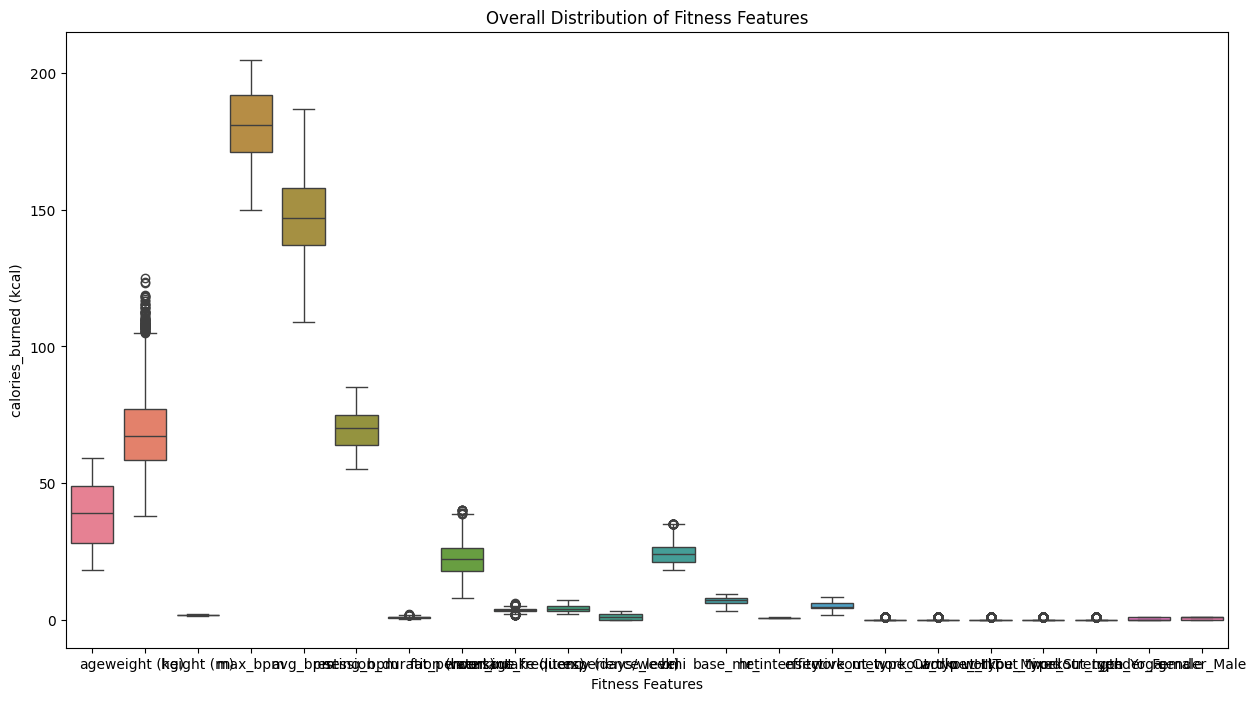

In [12]:
# EDA
import matplotlib.pyplot as plt
import seaborn as sns
x_features = [
    'age', 'weight (kg)', 'height (m)', 'max_bpm', 'avg_bpm', 'resting_bpm',
       'session_duration (hours)', 'fat_percentage', 'water_intake (liters)',
       'workout_frequency (days/week)', 'experience_level', 'bmi', 'base_met',
       'hr_intensity', 'effective_met',
       'workout_type_Cardio', 'workout_type_HIIT', 'workout_type_Mixed',
       'workout_type_Strength', 'workout_type_Yoga', 'gender_Female',
       'gender_Male'
]

plt.figure(figsize=(15, 8))

#Pass the list of columns to x (lowercase) and target to y
# We use df[x_features] to slice the columns correctly
sns.boxplot(data=df_encoded[x_features])

plt.xlabel("Fitness Features")
plt.ylabel("calories_burned (kcal)")
plt.title("Overall Distribution of Fitness Features")
plt.show()

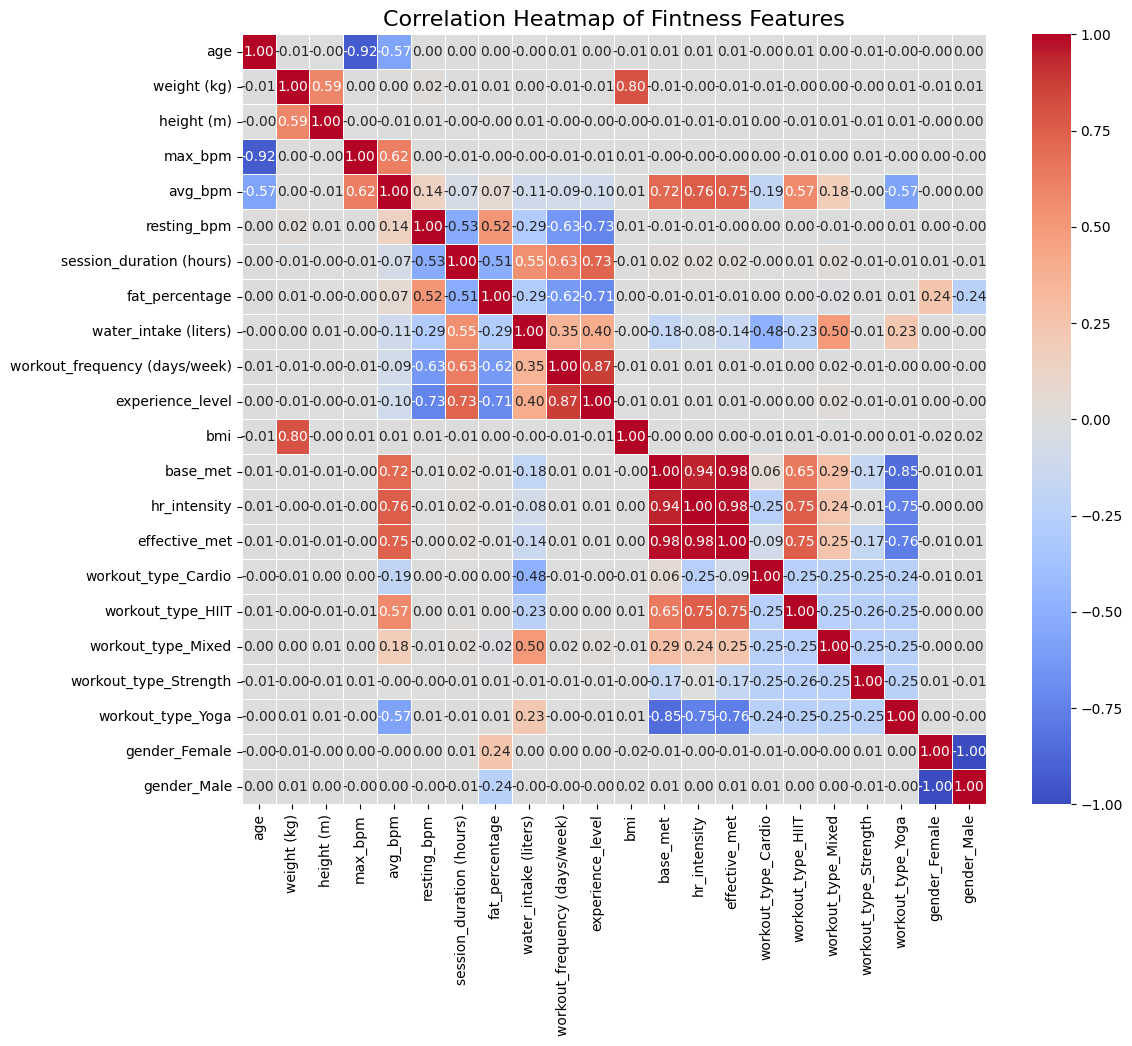

['corr_matrix.joblib']

In [14]:
# correlation Heatmap

import joblib

corr_matrix = df_encoded[x_features].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Fintness Features", fontsize=16)
plt.show()

# saved the encoding as joblib
joblib.dump(corr_matrix, "corr_matrix.joblib")

In [15]:
# Interpretation - correlation heatmap shows strongly differnet variables relate to each other. The value range from -1 to 1.

In [16]:
#outliers

q1 = df.quantile(0.25, numeric_only = True)
q3 = df.quantile(0.75, numeric_only = True)
iqr = q3 - q1

lower_threshold = q1 - 1.5 * iqr
upper_threshold = q3 + 1.5 * iqr

# cliping the outeliers
df['weight (kg)'] = df['weight (kg)'].clip(
    lower_threshold['weight (kg)'],
    upper_threshold['weight (kg)']
)
df['session_duration (hours)'] = df['session_duration (hours)'].clip(
    lower_threshold['session_duration (hours)'],
    upper_threshold['session_duration (hours)']
)
df['fat_percentage'] = df['fat_percentage'].clip(
    lower_threshold['fat_percentage'],
    upper_threshold['fat_percentage']
)
df['water_intake (liters)'] = df['water_intake (liters)'].clip(
    lower_threshold['water_intake (liters)'],
    upper_threshold['water_intake (liters)']
)
df['bmi'] = df['bmi'].clip(
    lower_threshold['bmi'],
    upper_threshold['bmi']
)
df['base_met'] = df['base_met'].clip(
    lower_threshold['base_met'],
    upper_threshold['base_met']
)
df['calories_burned (kcal)'] = df['calories_burned (kcal)'].clip(
    lower_threshold['calories_burned (kcal)'],
    upper_threshold['calories_burned (kcal)']
)

In [17]:
for col in df.select_dtypes(include=np.number).columns:
  iqr = df[col].quantile(0.75) - df[col].quantile(0.25)
  upper_bound = df[col].quantile(0.75) + 1.5 * iqr
  lower_bound = df[col].quantile(0.25) - 1.5 * iqr
  print(f"Column : {col} NumberOutliers: {df.loc[(df[col] <= lower_bound) | (df[col] >= upper_bound), :].shape[0]}")

Column : age NumberOutliers: 0
Column : weight (kg) NumberOutliers: 94
Column : height (m) NumberOutliers: 0
Column : max_bpm NumberOutliers: 0
Column : avg_bpm NumberOutliers: 0
Column : resting_bpm NumberOutliers: 0
Column : session_duration (hours) NumberOutliers: 31
Column : fat_percentage NumberOutliers: 11
Column : water_intake (liters) NumberOutliers: 124
Column : workout_frequency (days/week) NumberOutliers: 0
Column : experience_level NumberOutliers: 0
Column : bmi NumberOutliers: 39
Column : base_met NumberOutliers: 2770
Column : hr_intensity NumberOutliers: 0
Column : effective_met NumberOutliers: 0
Column : calories_burned (kcal) NumberOutliers: 284


In [18]:
df_encoded.columns

Index(['age', 'weight (kg)', 'height (m)', 'max_bpm', 'avg_bpm', 'resting_bpm',
       'session_duration (hours)', 'fat_percentage', 'water_intake (liters)',
       'workout_frequency (days/week)', 'experience_level', 'bmi', 'base_met',
       'hr_intensity', 'effective_met', 'calories_burned (kcal)',
       'workout_type_Cardio', 'workout_type_HIIT', 'workout_type_Mixed',
       'workout_type_Strength', 'workout_type_Yoga', 'gender_Female',
       'gender_Male'],
      dtype='object')

In [19]:
import pandas as pd

# Split

from sklearn.model_selection import train_test_split
import joblib

x_features = [
    'age', 'weight (kg)', 'height (m)', 'max_bpm', 'avg_bpm', 'resting_bpm',
       'session_duration (hours)', 'fat_percentage', 'water_intake (liters)',
       'workout_frequency (days/week)', 'experience_level', 'bmi', 'base_met',
       'hr_intensity', 'effective_met',
       'workout_type_Cardio', 'workout_type_HIIT', 'workout_type_Mixed',
       'workout_type_Strength', 'workout_type_Yoga', 'gender_Female',
       'gender_Male'
]

X = df_encoded[x_features].values
y = df_encoded['calories_burned (kcal)'].values

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.30)

# trained model saved as a joblib file
train_df = pd.DataFrame(X_train, columns=x_features)
train_df['calories_burned (kcal)'] = y_train
joblib.dump(train_df, "train_data.joblib")

['train_data.joblib']

In [20]:
#scale
from sklearn.preprocessing import StandardScaler
import numpy as np

scaler = StandardScaler()
scaler.fit(X_train) # will calculate the values of mean and sd

X_train_scaled = scaler.transform(X_train) # train data
X_test_scaled  = scaler.transform(X_test) # test data


import joblib

# Save the scaler to a pkl file
joblib.dump(scaler, "scaler.pkl")

#loaded_scaler = joblib.load("scaler.pkl")

['scaler.pkl']

In [21]:
print(X_train, X_train_scaled)

[[22.   56.8   1.78 ...  0.    1.    0.  ]
 [33.   81.1   1.69 ...  0.    1.    0.  ]
 [18.   47.7   1.46 ...  0.    1.    0.  ]
 ...
 [46.   76.9   1.8  ...  0.    0.    1.  ]
 [38.   57.3   1.78 ...  0.    1.    0.  ]
 [29.   77.2   1.73 ...  0.    0.    1.  ]] [[-1.36856025 -0.85720743  1.01985407 ... -0.49854329  1.02078118
  -1.02078118]
 [-0.45184439  0.96336142  0.09605196 ... -0.49854329  1.02078118
  -1.02078118]
 [-1.70191147 -1.53898425 -2.26477566 ... -0.49854329  1.02078118
  -1.02078118]
 ...
 [ 0.63154708  0.6486952   1.22514343 ... -0.49854329 -0.97964189
   0.97964189]
 [-0.03515537 -0.81974717  1.01985407 ... -0.49854329  1.02078118
  -1.02078118]
 [-0.78519562  0.67117136  0.50663068 ... -0.49854329 -0.97964189
   0.97964189]]


In [25]:
# Linear Regression
y_pred = model.predict(X_test)
y_pred

array([722.087, 564.317, 257.029, ..., 430.65 , 429.868, 422.585])

In [27]:
from sklearn import metrics
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Mean Absolute Error: 4.388624911368471
Mean Squared Error: 95.62805201938077
Root Mean Squared Error: 9.778959659359515


In [26]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.9968664177928377

In [28]:
# KNN
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train) # model is trained

knn.predict(X_test_scaled) # predict on test/validation data


from sklearn.metrics import r2_score

r2_score(y_test, knn.predict(X_test_scaled))

0.9429544898690233

In [29]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

dt = DecisionTreeRegressor()

dt.fit(X_train, y_train)

from sklearn.model_selection import cross_val_score

cross_val_score(dt, X_train, y_train, cv=10, scoring = 'r2').mean()

np.float64(0.9901354335140831)

In [30]:
# Random forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(max_features = 'sqrt', max_depth = 5, n_estimators = 100)

rf.fit(X_train, y_train)

cross_val_score(rf, X_train, y_train, cv=10, scoring = 'r2').mean()

np.float64(0.8610687642429591)

In [23]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import joblib


model = RandomForestRegressor()
model.fit(X_train, y_train)

# Save the model as a pickle file using joblib
joblib.dump(model, "random_forest_model.pkl")



['random_forest_model.pkl']

In [31]:
from xgboost import XGBRegressor # import

xgb = XGBRegressor()

xgb.fit(X_train, y_train)

xgb.predict(X_test)


from sklearn.metrics import r2_score

r2_score(y_test, xgb.predict(X_test))

0.9973558707550016

**Unsupervised Learning**



In [32]:
df.shape

(14102, 18)

In [33]:
df.duplicated().sum()

np.int64(0)

In [34]:
df.isna().sum()

,0
age,0
gender,0
weight (kg),0
height (m),0
max_bpm,0
avg_bpm,0
resting_bpm,0
session_duration (hours),0
workout_type,0
fat_percentage,0


In [35]:
# encoding
import pandas as pd
import joblib

df_encoded = pd.get_dummies(df, columns=['workout_type', 'gender'], dtype=int)

print(df_encoded)

# saved the encoding as joblib
joblib.dump(df_encoded, "df_encoded.joblib")

       age  weight (kg)  height (m)  max_bpm  avg_bpm  resting_bpm  \
0       56         53.8        1.62    163.0    149.0         71.0   
1       46         54.9        1.75    170.0    126.0         73.0   
2       32         68.5        1.61    190.0    171.0         60.0   
3       25         98.8        1.86    189.0    135.0         69.0   
4       38         95.5        1.71    176.0    138.0         66.0   
...    ...          ...         ...      ...      ...          ...   
14097   18         75.7        1.76    205.0    143.0         67.0   
14098   54         66.4        1.71    162.0    131.0         73.0   
14099   23         74.7        1.52    204.0    161.0         61.0   
14100   43         70.8        1.69    171.0    154.0         55.0   
14101   19         87.3        1.60    205.0    156.0         64.0   

       session_duration (hours)  fat_percentage  water_intake (liters)  \
0                          1.01            22.1                    3.5   
1          

['df_encoded.joblib']

In [77]:
df_encoded = df_encoded.drop(columns=['workout_type_Cardio', 'workout_type_HIIT', 'workout_type_Mixed',
       'workout_type_Strength', 'workout_type_Yoga'])

In [78]:
df_encoded.columns

Index(['age', 'weight (kg)', 'height (m)', 'max_bpm', 'avg_bpm', 'resting_bpm',
       'session_duration (hours)', 'fat_percentage', 'water_intake (liters)',
       'workout_frequency (days/week)', 'experience_level', 'bmi', 'base_met',
       'hr_intensity', 'effective_met', 'calories_burned (kcal)',
       'gender_Female', 'gender_Male'],
      dtype='object')

In [37]:
#outliers

q1 = df.quantile(0.25, numeric_only = True)
q3 = df.quantile(0.75, numeric_only = True)
iqr = q3 - q1

lower_threshold = q1 - 1.5 * iqr
upper_threshold = q3 + 1.5 * iqr

#cliping the outliers
df['weight (kg)'] = df['weight (kg)'].clip(
    lower_threshold['weight (kg)'],
    upper_threshold['weight (kg)']
)
df['session_duration (hours)'] = df['session_duration (hours)'].clip(
    lower_threshold['session_duration (hours)'],
    upper_threshold['session_duration (hours)']
)
df['fat_percentage'] = df['fat_percentage'].clip(
    lower_threshold['fat_percentage'],
    upper_threshold['fat_percentage']
)
df['water_intake (liters)'] = df['water_intake (liters)'].clip(
    lower_threshold['water_intake (liters)'],
    upper_threshold['water_intake (liters)']
)
df['bmi'] = df['bmi'].clip(
    lower_threshold['bmi'],
    upper_threshold['bmi']
)
df['base_met'] = df['base_met'].clip(
    lower_threshold['base_met'],
    upper_threshold['base_met']
)
df['calories_burned (kcal)'] = df['calories_burned (kcal)'].clip(
    lower_threshold['calories_burned (kcal)'],
    upper_threshold['calories_burned (kcal)']
)

In [38]:
for col in df.select_dtypes(include=np.number).columns:
  iqr = df[col].quantile(0.75) - df[col].quantile(0.25)
  upper_bound = df[col].quantile(0.75) + 1.5 * iqr
  lower_bound = df[col].quantile(0.25) - 1.5 * iqr
  print(f"Column : {col} NumberOutliers: {df.loc[(df[col] <= lower_bound) | (df[col] >= upper_bound), :].shape[0]}")

Column : age NumberOutliers: 0
Column : weight (kg) NumberOutliers: 94
Column : height (m) NumberOutliers: 0
Column : max_bpm NumberOutliers: 0
Column : avg_bpm NumberOutliers: 0
Column : resting_bpm NumberOutliers: 0
Column : session_duration (hours) NumberOutliers: 31
Column : fat_percentage NumberOutliers: 11
Column : water_intake (liters) NumberOutliers: 124
Column : workout_frequency (days/week) NumberOutliers: 0
Column : experience_level NumberOutliers: 0
Column : bmi NumberOutliers: 39
Column : base_met NumberOutliers: 2770
Column : hr_intensity NumberOutliers: 0
Column : effective_met NumberOutliers: 0
Column : calories_burned (kcal) NumberOutliers: 284


In [88]:
# scale

from sklearn.preprocessing import StandardScaler
import numpy as np
scaler = StandardScaler()

X = df_encoded.values
X_scaled = scaler.fit_transform(X)

import joblib

# 1. Save the scaler to a file
joblib.dump(scaler, "scaler.joblib")

# 2. How to load it back later (e.g., in your Streamlit app)
#loaded_scaler = joblib.load("scaler.pkl")

In [87]:
# PCA
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

#  ADD X_FEATURES LIST
x_features = [
    'age', 'weight (kg)', 'height (m)', 'max_bpm', 'avg_bpm', 'resting_bpm',
       'session_duration (hours)', 'fat_percentage', 'water_intake (liters)',
       'workout_frequency (days/week)', 'experience_level', 'bmi', 'base_met',
       'hr_intensity', 'effective_met', 'calories_burned (kcal)', 'gender_Female',
       'gender_Male']

# FILTER YOUR DATAFRAME HERE
features_df = df_encoded[x_features]

# Standardize the data (Pass the filtered features_df here)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(features_df)

# Apply PCA
pca = PCA(n_components=2)   # reduce to 2 principal components
pca_result = pca.fit_transform(scaled_data)

# Create a DataFrame with PCA results
pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])

print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("\nPCA Result:\n", pca_df)

Explained Variance Ratio: [0.2431746  0.21871264]

PCA Result:
             PC1       PC2
0      1.429597 -1.320029
1     -4.035967  0.923307
2      1.199077 -2.734622
3     -2.649629  0.902917
4     -1.408112 -1.202016
...         ...       ...
14097 -2.181939  1.090421
14098 -0.791052  0.546298
14099  0.729627  0.149246
14100  4.446020  1.239123
14101  2.224529  1.542217

[14102 rows x 2 columns]


In [80]:
# kmeans

from sklearn.cluster import KMeans # import

kmeans = KMeans(n_clusters=4)

kmeans.fit(X_scaled)

KMeans(n_clusters=4)

In [81]:
kmeans.cluster_centers_

array([[-5.33870336e-03,  1.95974088e-02,  1.41570728e-02,
        -6.43566574e-03, -1.16170435e+00,  1.57092458e-02,
        -2.60463956e-02,  2.29237816e-02,  4.60027261e-01,
        -8.14523465e-03, -1.84312400e-02,  1.42341486e-02,
        -1.70930836e+00, -1.51269731e+00, -1.54181874e+00,
        -1.11433526e+00, -4.94853457e-01, -5.08583938e-01,
        -5.00177274e-01, -5.01949325e-01,  2.02261581e+00,
         8.62588769e-03, -8.62588769e-03],
       [-1.23101605e-02, -7.95250848e-03, -1.39729416e-02,
         1.80243110e-02, -1.89851963e-03, -9.18136723e-03,
        -2.86333651e-02,  1.08420912e-02, -2.17320553e-02,
        -1.29084229e-02, -1.54040842e-02, -6.65529585e-04,
        -3.33392698e-01, -1.51393848e-02, -3.41092362e-01,
        -2.54310037e-01, -4.94853457e-01, -5.08583938e-01,
        -5.00177274e-01,  1.99223298e+00, -4.94409266e-01,
         1.21842763e-02, -1.21842763e-02],
       [ 9.25630563e-03,  1.82302462e-03,  3.45329217e-05,
        -5.84246247e-03,  7.5

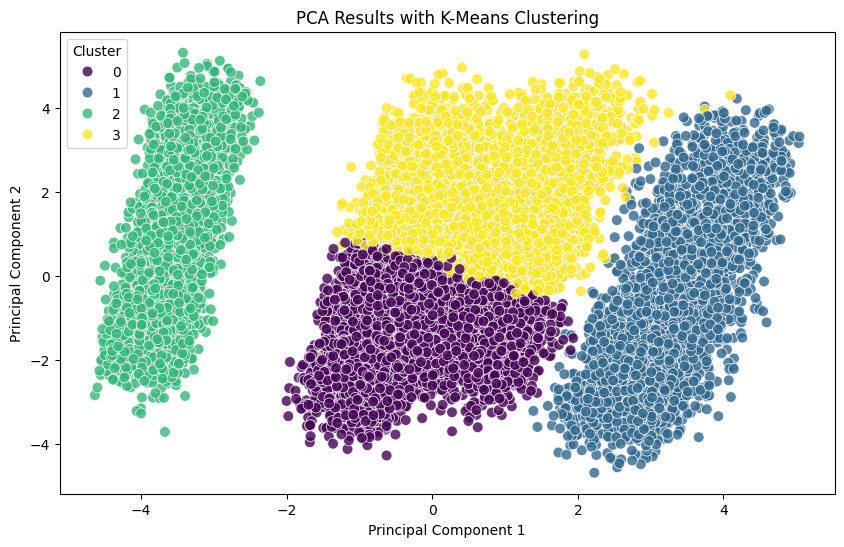

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

pca_df['Cluster'] = kmeans.labels_

plt.figure(figsize=(10,6))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster', # Corrected: Changed 'cluster' to 'Cluster'
    data=pca_df,
    palette='viridis',
    s=60,
    alpha=0.8,
)

plt.title('PCA Results with K-Means Clustering')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

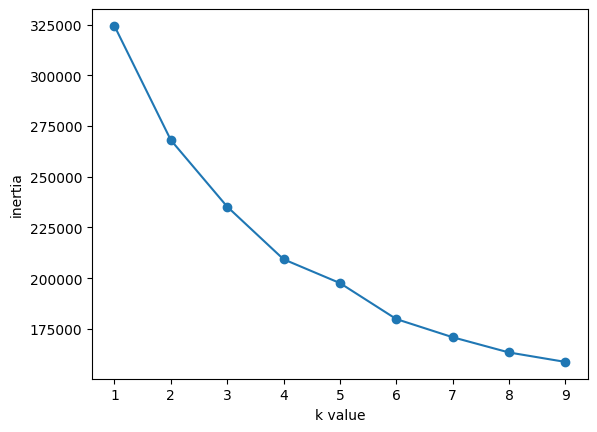

In [66]:
# Elbow plot
import matplotlib.pyplot as plt

inertias = []

for k in range(1, 10):
  kmeans = KMeans(n_clusters=k)
  kmeans.fit(X_scaled)
  inertias.append(kmeans.inertia_)

plt.plot(range(1, 10), inertias, marker='o')
plt.xlabel('k value')
plt.ylabel('inertia')
plt.show()

In [53]:
 # Best value of k is 4 which is in_line

In [90]:
import joblib

final_model = KMeans(n_clusters=4)
final_model.fit(X_scaled)

joblib.dump(final_model, "kmeans_model.joblib")

['kmeans_model.joblib']

In [82]:
from sklearn.metrics import silhouette_score

silhouette_score(X_scaled, kmeans.labels_)

np.float64(0.189366896934203)

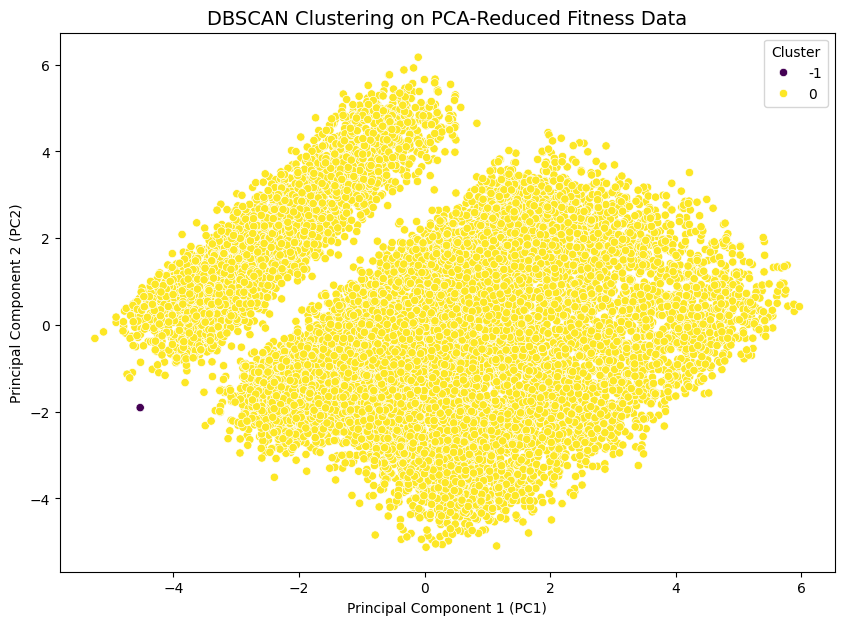

In [84]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import seaborn as sns


dbscan = DBSCAN(eps=0.5, min_samples=5)
pca_df['Cluster'] = dbscan.fit_predict(pca_result)

# Outliers/Noise points are automatically labeled as -1 by DBSCAN

# Visualize the DBSCAN clusters
plt.figure(figsize=(10, 7))

# Plot the clusters using a scatter plot
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    data=pca_df,
    palette='viridis')

plt.title("DBSCAN Clustering on PCA-Reduced Fitness Data", fontsize=14)
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.show()
